<a href="https://colab.research.google.com/github/radubhattarai/Hands-on-LLM/blob/main/Chapter_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1> <b>Chapter 2 </b>- Tokens and Token Embeddings

foundational building blocks of Large Language Models (LLMs)

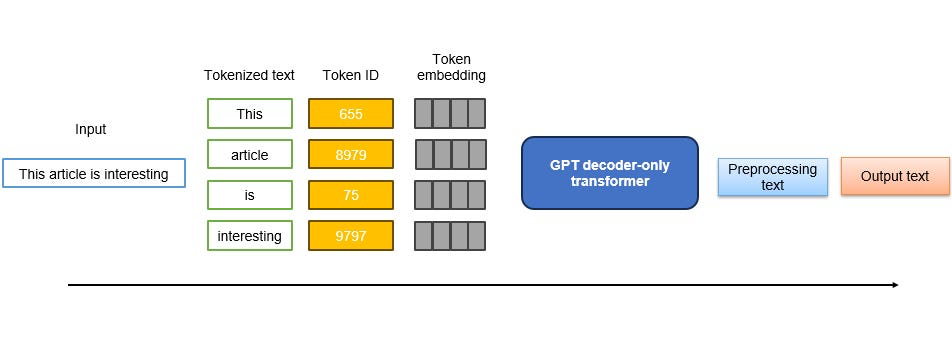


**Downloading and Running An LLM**

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

# Load model and tokenizer
model = AutoModelForCausalLM.from_pretrained(
    "microsoft/Phi-3-mini-4k-instruct",
    device_map="cuda",
    torch_dtype="auto",
    trust_remote_code=False,
)
tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3-mini-4k-instruct")

our first step is to load our model onto the GPU for faster inference. Note that we load the model and tokenizer separately and keep them as such so that we can explore them separately.

In [ ]:
prompt = "Write an email apologizing to my teacher why i was absent. Explain how it happened.<|assistant|>"

# Tokenize the input prompt
input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to("cuda")

# Generate the text
generation_output = model.generate(
  input_ids=input_ids,
  max_new_tokens=20
)

# Print the output
print(tokenizer.decode(generation_output[0]))

In [ ]:
print(input_ids)

In [ ]:
for id in input_ids[0]:
   print(tokenizer.decode(id))

In [ ]:
print(tokenizer.decode(3323))
print(tokenizer.decode(622))
print(tokenizer.decode([3323, 622]))
print(tokenizer.decode(29901))

# Comparing Trained LLM Tokenizers

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

colors_list = [
    '102;194;165', '252;141;98', '141;160;203',
    '231;138;195', '166;216;84', '255;217;47'
]

def show_tokens(sentence, tokenizer_name):
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    token_ids = tokenizer(sentence).input_ids
    for idx, t in enumerate(token_ids):
        print(
            f'\x1b[0;30;48;2;{colors_list[idx % len(colors_list)]}m' +
            tokenizer.decode(t) +
            '\x1b[0m',
            end=' '
        )

We’ll use a number of tokenizers to encode the following text:

In [ ]:
text = """
English and CAPITALIZATION
🎵 鸟
show_tokens False None elif == >= else: two tabs:"    " Three tabs: "       "
12.0*50=600
"""

**Lets Start how different model in history start with tokenization**

**BERT base model (uncased) (2018)**
<br>
Tokenization method: WordPiece

---



In [ ]:
show_tokens(text, "bert-base-uncased")

**BERT base model (cased) (2018)** <br>
Tokenization method: WordPiece

In [ ]:
show_tokens(text, "bert-base-cased")

**GPT-2 (2019)** <br>
Tokenization Method: Byte Pair encoding


In [ ]:
show_tokens(text,"gpt2")

**google/flan-t5-small**

In [ ]:
show_tokens(text, "google/flan-t5-small")

# The official is `tiktoken` but this the same tokenizer on the HF platform


In [ ]:
show_tokens(text, "Xenova/gpt-4")

In [ ]:
show_tokens(text, "facebook/galactica-1.3b")

In [ ]:
show_tokens(text, "microsoft/Phi-3-mini-4k-instruct")

# Contextualized Word Embeddings From a Language Model (Like BERT)